# 1



In [ ]:
import numpy as np

def GetSplineSlopes(x, y, alpha, beta, type="C"):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    dx = np.diff(x)
    ydiv = np.diff(y) / dx
    N = len(x)

    A = np.zeros((N, N))
    rhs = np.zeros(N)

    for i in range(N - 2):
        A[i + 1, i] = dx[i + 1]
        A[i + 1, i + 1] = 2 * (dx[i] + dx[i + 1])
        A[i + 1, i + 2] = dx[i]
        rhs[i + 1] = 3 * (dx[i + 1] * ydiv[i] + dx[i] * ydiv[i + 1])

    if type == "C":
        A[0, 0] = 1.0
        rhs[0] = alpha
        A[-1, -1] = 1.0
        rhs[-1] = beta 
    if type == "N":
        A[0, 0] = 2.0
        A[0, 1] = 1.0
        rhs[0] = 3 * ydiv[0] - 0.5 * alpha * dx[0]
        A[-1, -2] = 1.0
        A[-1, -1] = 2.0
        rhs[-1] = 3 * ydiv[-1] + 0.5 * beta * dx[-1]
    

    slopes = np.linalg.solve(A, rhs)
    return slopes


# 2


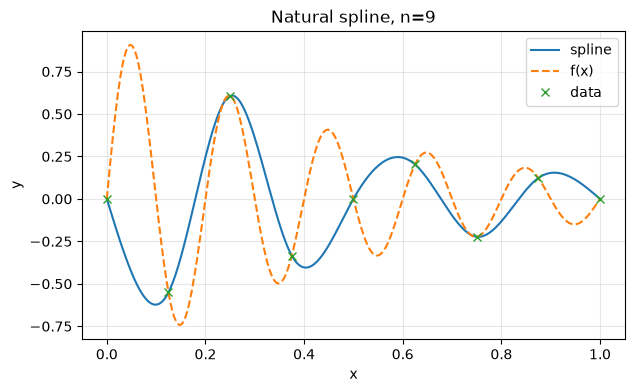

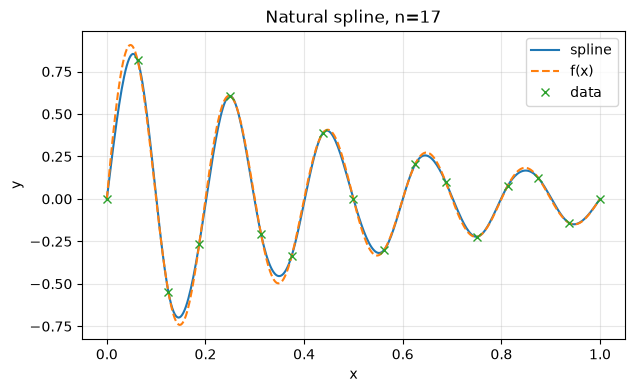

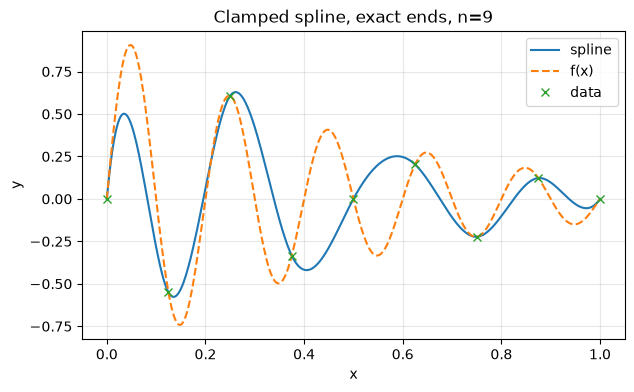

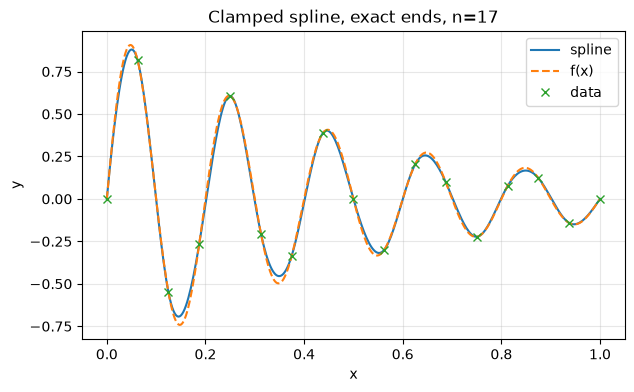

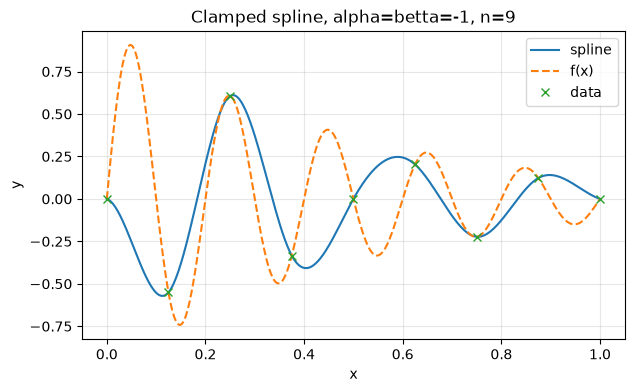

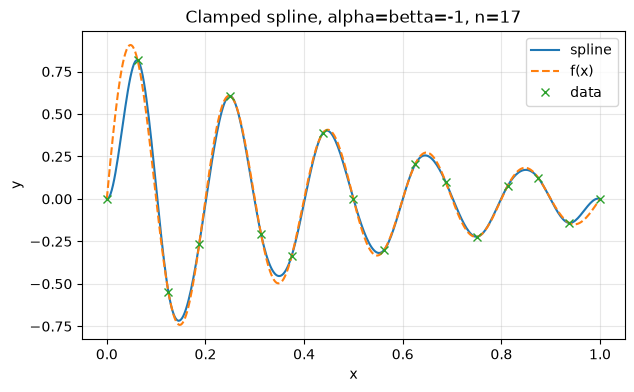

array([ -1.        ,  -2.11478695, -16.97422733,  18.25161407,
        -0.48538216, -13.51751554,   9.4093202 ,   4.19860124,
       -10.1710727 ,   3.60232679,   5.4860608 ,  -6.50509987,
         0.09979572,   5.07858793,  -3.80581652,  -0.27306667,
        -1.        ])

In [20]:
import matplotlib.pyplot as plt

def f(x):
    return np.exp(-2 * x) * np.sin(10 * np.pi * x)

def fprime(x):
    return np.exp(-2 * x) * (-2 * np.sin(10 * np.pi * x) + 10 * np.pi * np.cos(10 * np.pi * x))


def eval_hermite_spline(x_nodes, y, slopes, x_eval):
    x_nodes = np.asarray(x_nodes, float)
    y = np.asarray(y, float)
    slopes = np.asarray(slopes, float)
    x_eval = np.asarray(x_eval, float)
    S = np.empty_like(x_eval)
    for k, xk in enumerate(x_eval):
        i = int(np.clip(np.searchsorted(x_nodes, xk, side="right") - 1, 0, len(x_nodes) - 2))
        h = x_nodes[i + 1] - x_nodes[i]
        t = (xk - x_nodes[i]) / h
        S[k] = (
            y[i] * (2 * t**3 - 3 * t**2 + 1)
            + h * slopes[i] * (t**3 - 2 * t**2 + t)
            + y[i + 1] * (-2 * t**3 + 3 * t**2)
            + h * slopes[i + 1] * (t**3 - t**2)
        )
    return S


def plot_hermite_spline(n, kind, alpha=0.0, beta=0.0, title=None):
    x = np.linspace(0, 1, n)
    y = f(x)
    s = GetSplineSlopes(x, y, alpha, beta, type=kind)

    xx = np.linspace(0, 1, 400)
    S = eval_hermite_spline(x, y, s, xx)

    plt.figure(figsize=(7, 4))
    plt.plot(xx, S, "-", label="spline")
    plt.plot(xx, f(xx), "--", label="f(x)")
    plt.plot(x, y, "x", label="data")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title or f"{kind}, n={n}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    return s


plot_hermite_spline(9, "N", 0, 0, "Natural spline, n=9")
plot_hermite_spline(17, "N", 0, 0, "Natural spline, n=17")

plot_hermite_spline(9, "C", fprime(0), fprime(1), "Clamped spline, exact ends, n=9")
plot_hermite_spline(17, "C", fprime(0), fprime(1), "Clamped spline, exact ends, n=17")

plot_hermite_spline(9, "C", -1, -1, "Clamped spline, alpha=betta=-1, n=9")
plot_hermite_spline(17, "C", -1, -1, "Clamped spline, alpha=betta=-1, n=17")


# 4


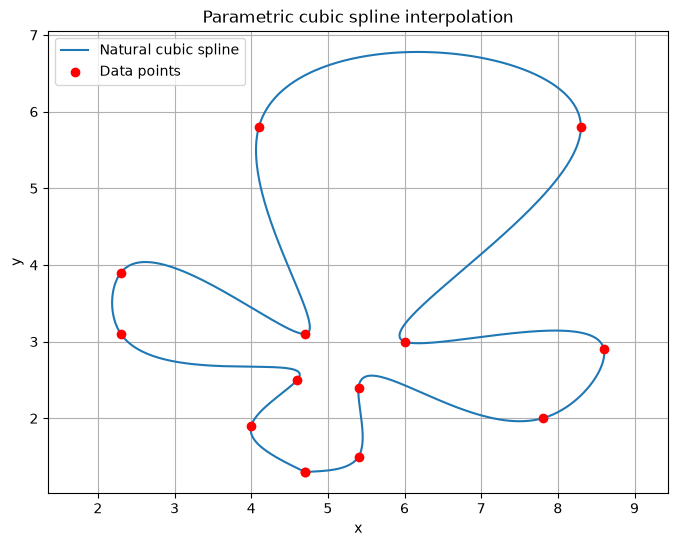

In [22]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([4.7, 4.0, 4.6, 2.3, 2.3, 4.7, 4.1,
              8.3, 6.0, 8.6, 7.8, 5.4, 5.4, 4.7])

y = np.array([1.3, 1.9, 2.5, 3.1, 3.9, 3.1, 5.8,
              5.8, 3.0, 2.9, 2.0, 2.4, 1.5, 1.3])

dx = np.diff(x)
dy = np.diff(y)

dlambda = np.sqrt(dx**2 + dy**2)
lam = np.concatenate(([0], np.cumsum(dlambda)))



sx_slopes = GetSplineSlopes(lam, x, 0.0, 0.0, type="N")
sy_slopes = GetSplineSlopes(lam, y, 0.0, 0.0, type="N")

lam_fine = np.linspace(lam[0], lam[-1], 1000)
x_fine = eval_hermite_spline(lam, x, sx_slopes, lam_fine)
y_fine = eval_hermite_spline(lam, y, sy_slopes, lam_fine)

plt.figure(figsize=(8, 6))
plt.plot(x_fine, y_fine, label="Natural cubic spline")
plt.scatter(x, y, color="red", zorder=3, label="Data points")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Parametric cubic spline interpolation")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# 5


In [37]:
def get_A(n):
  return np.array([[1/(i + j - 1) for j in range(1, n + 1)] for i in range(1, 11)])

def get_c(n):
  return np.ones(n)

def get_b(n):
  return get_A(n) @ get_c(n)

def least_squares(n):
  A = get_A(n)
  b = get_b(n)
  
  return np.linalg.inv(A.T @ A) @ A.T @ b


print(least_squares(6))
print()
print(least_squares(8))
print()
print(f"Condition number of A.T @ A 10*6: {np.linalg.cond(get_A(6).T @ get_A(6))}")
print(f"Condition number of A.T @ A 10*8: {np.linalg.cond(get_A(8).T @ get_A(8))}")

[0.99990819 1.00024825 0.99999254 0.99977193 1.00027157 0.99991855]

[  6.80081946  -7.89984404 -29.83960048  97.77164881 -73.96655108
  11.63142238   3.24110382   0.88491136]

Condition number of A.T @ A 10*6: 6004941862896.767
Condition number of A.T @ A 10*8: 5.489063089463325e+17


# 6

In [42]:
A = np.array([[-4, -2, 4], [-4, 7, -5]])

Q, R = np.linalg.qr(A.T)

print(Q)
print(R)


[[-0.66666667  0.66666667]
 [-0.33333333 -0.66666667]
 [ 0.66666667  0.33333333]]
[[ 6. -3.]
 [ 0. -9.]]
